# 1. Title & Problem Statement
# Capstone Project: Cease & Desist Document Processing System

"""
Objective:
Build a multi-agent AI system to process Cease & Desist documents.

Features:
- Classification (Cease / Irrelevant / Uncertain)
- Information Extraction
- Validation
- Human-in-the-Loop (HITL)
- Audit Logging
- Multi-model hybrid architecture

Models Used:
- Groq (fast classification)
- OpenAI (accurate extraction)
- HuggingFace (fallback)
"""

# 2. Install Dependencies

In [23]:
!pip install -q \
langchain langgraph langchain-openai langchain-groq \
python-dotenv pymupdf pydantic openai groq \
huggingface_hub pillow

# 3. Load Environment Variables

In [24]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HF_TOKEN = os.getenv("HUGGINGFACEHUB_API_TOKEN")

assert OPENAI_API_KEY, "Missing OpenAI Key"
assert GROQ_API_KEY, "Missing Groq Key"
assert HF_TOKEN, "Missing HF Token"

print("✅ Keys loaded successfully")

✅ Keys loaded successfully


# 4. Initialize Models
🟢 Groq (Classification)

In [25]:
from langchain_groq import ChatGroq

groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model_name="llama-3.3-70b-versatile",
    temperature=0
)

🔵 OpenAI (Extraction)

In [ ]:
from langchain_openai import ChatOpenAI

groq_llm = ChatOpenAI(
    api_key=OPENAI_API_KEY,
    model="gpt-4o-mini",
    temperature=0
)

# Error Handler

In [27]:
def handle_error(error_type, state, error_msg=""):
    log = {
        "error_type": error_type,
        "message": error_msg
    }

    # -----------------------------
    # FILE LOAD ERROR
    # -----------------------------
    if error_type == "file_load":
        log["action"] = "Retry with fallback loader"
        state["text"] = "Unable to load document"
        state["chunks"] = [state["text"]]

    # -----------------------------
    # OCR ERROR
    # -----------------------------
    elif error_type == "ocr":
        log["action"] = "Mark as unclear → send to HITL"
        state["text"] = "SCANNED DOCUMENT: Poor quality"
        state["chunks"] = [state["text"]]

    # -----------------------------
    # CLASSIFICATION ERROR
    # -----------------------------
    elif error_type == "classification":
        log["action"] = "Fallback to rule-based classification"
        state["classification"] = {
            "label": "Uncertain",
            "confidence": 0.5
        }

    # -----------------------------
    # EXTRACTION ERROR
    # -----------------------------
    elif error_type == "extraction":
        log["action"] = "Flag for human review"
        state["extracted_data"] = {
            "error": "Extraction failed",
            "needs_review": True
        }

    # -----------------------------
    # LOG ERROR
    # -----------------------------
    if "audit_logs" not in state:
        state["audit_logs"] = []

    state["audit_logs"].append(log)

    return state

from datetime import datetime

def log_error(state, error_type, message, action):
    """
    Centralized error logger for all agents/tools
    """

    # ensure audit_logs exists
    if "audit_logs" not in state:
        state["audit_logs"] = []

    log_entry = {
        "timestamp": str(datetime.now()),
        "error_type": error_type,
        "message": str(message),
        "action": action
    }

    state["audit_logs"].append(log_entry)

    return state

# 5. Define State (LangGraph Memory)
* LangGraph state management

In [28]:
from typing import TypedDict, List, Dict, Annotated
from langgraph.graph import add_messages
from langchain.tools import tool
import fitz
import os
import json
import re
from typing_extensions import TypedDict
import operator

class State(TypedDict):
    file_path: str
    doc_name: str
    text: str
    chunks: list
    classification: dict
    extracted_data: dict
    validation: str
    confidence_score: float
    audit_logs: Annotated[list, operator.add]

# 6. Document Loader Tool
* Based on the tools

In [29]:
# -----------------------------
# Detect scanned PDF
# -----------------------------
@tool
def is_scanned_pdf_tool(file_path: str) -> bool:
    """Check whether PDF is scanned (no embedded text present)."""
    try:
        doc = fitz.open(file_path)

        for page in doc:
            if page.get_text().strip():
                return False

        return True

    except Exception:
        return True  # fallback → treat as scanned


# -----------------------------
# Extract text PDF
# -----------------------------
@tool
def extract_text_pdf_tool(file_path: str) -> str:
    """Extract text from a standard text-based PDF."""
    try:
        doc = fitz.open(file_path)
        text = ""

        for page in doc:
            text += page.get_text()

        return text if text.strip() else "EMPTY DOCUMENT"

    except Exception:
        return "ERROR: Unable to read document"


# -----------------------------
# OCR fallback
# -----------------------------
@tool
def extract_text_fallback_tool(file_path: str) -> str:
    """Fallback extraction for scanned PDFs (no OCR)."""
    return "SCANNED DOCUMENT: Unable to extract content. Please review manually."


# -----------------------------
# Chunking
# -----------------------------
@tool
def chunk_text_tool(text: str) -> list:
    """Split text into overlapping chunks for LLM processing."""
    try:
        chunks = []
        chunk_size = 500
        overlap = 50
        start = 0

        while start < len(text):
            chunk = text[start:start + chunk_size]
            chunks.append(chunk)
            start += chunk_size - overlap

        return chunks if chunks else [text]

    except Exception:
        return [text]


# -----------------------------
# Loader Tool (FINAL)
# -----------------------------
@tool
def load_document_tool(file_path: str) -> dict:
    """Load document, detect type, extract text, and create chunks with error handling."""

    state = {
        "doc_name": os.path.basename(file_path),
        "text": "",
        "chunks": [],
        "audit_logs": []
    }

    print(f"\nProcessing: {file_path}")

    try:
        # -----------------------------
        # Detect type
        # -----------------------------
        try:
            is_scanned = is_scanned_pdf_tool.invoke(file_path)
        except Exception as e:
            log_error(state, "file_load", e, "Defaulting to scanned")
            is_scanned = True

        # -----------------------------
        # Extract
        # -----------------------------
        if is_scanned:
            print("📸 Image-based PDF")

            try:
                text = extract_text_fallback_tool.invoke(file_path)
            except Exception as e:
                log_error(state, "ocr", e, "Fallback text used")
                text = "SCANNED DOCUMENT: Unable to extract content."

        else:
            print("Text-based PDF")

            try:
                text = extract_text_pdf_tool.invoke(file_path)
            except Exception as e:
                log_error(state, "file_load", e, "Fallback text used")
                text = "ERROR: Unable to read document."

        # -----------------------------
        # Clean text
        # -----------------------------
        if not text or text.strip() == "":
            log_error(state, "empty_text", "No content extracted", "Marked as uncertain")
            text = "EMPTY DOCUMENT"

        text = text.replace("\n", " ").strip()

        # -----------------------------
        # Chunking
        # -----------------------------
        try:
            chunks = chunk_text_tool.invoke(text)
        except Exception as e:
            log_error(state, "chunking", e, "Single chunk fallback")
            chunks = [text]

        # -----------------------------
        # Final state
        # -----------------------------
        state["text"] = text
        state["chunks"] = chunks

        print(f"Chunks created: {len(chunks)}")

        return state

    except Exception as e:
        # Critical fallback
        log_error(state, "critical", e, "Minimal fallback state")

        state["text"] = "CRITICAL ERROR: Processing failed."
        state["chunks"] = [state["text"]]

        return state
    
def load_document(state):
    result = load_document_tool.invoke(state["file_path"])

    return {
        "doc_name": result["doc_name"],
        "text": result["text"],
        "chunks": result["chunks"],
        "audit_logs": result.get("audit_logs", [])
    }

# 7. Classification (Groq)
* Classification Agent + confidence scoring

In [30]:
def safe_json_parse(text):
    """Safely parse JSON from LLM output"""
    try:
        return json.loads(text)
    except:
        try:
            # attempt to fix common issues
            text = text.strip()
            text = text[text.find("{"):text.rfind("}")+1]
            return json.loads(text)
        except:
            return None


def merge_results(results):
    """Merge chunk-level outputs into single structured output"""
    final = {}

    for r in results:
        if not isinstance(r, dict):
            continue

        for k, v in r.items():
            if k not in final or final[k] in ["...", "Not Found", None]:
                final[k] = v

    return final

@tool
def classify_document_tool(text: str) -> dict:
    """Classify document using LLM into Cease / Irrelevant / Uncertain"""

    try:
        if not text or not isinstance(text, str):
            return {
                "label": "Uncertain",
                "confidence": 0.0,
                "reason": "Empty input"
            }

        prompt = f"""
        You are a document classification expert.

        Classify the following document into ONE of:
        - Cease (valid cease & desist request)
        - Irrelevant (not related)
        - Uncertain (not clear)

        Rules:
        - If request asks to stop communication → Cease
        - If unrelated business content → Irrelevant
        - If unclear / low quality → Uncertain

        Return STRICT JSON:
        {{
          "label": "Cease | Irrelevant | Uncertain",
          "confidence": 0-1,
          "reason": "short explanation"
        }}

        Text:
        {text}
        """

        response = groq_llm.invoke(prompt)

        result = safe_json_parse(response.content)

        # fallback if parsing fails
        if not result or "label" not in result:
            raise ValueError("Invalid LLM response")

        return result

    except Exception as e:
        return {
            "label": "Uncertain",
            "confidence": 0.0,
            "reason": f"LLM classification failed: {str(e)}"
        }

def classify_document(state):
    try:
        text = state["chunks"][0] if state.get("chunks") else state.get("text", "")

        result = classify_document_tool.invoke(text)

        log_error(state, "classification_info", result, "LLM classification completed")

        return {
            "classification": result
        }

    except Exception as e:
        log_error(state, "classification_error", str(e), "Fallback to Uncertain")

        return {
            "classification": {
                "label": "Uncertain",
                "confidence": 0.0,
                "reason": "Exception occurred"
            }
        }
    

# 8. Extraction (OpenAI + Fallback)
* Extraction Tool + fallback strategy

In [31]:
def extract_data(state):
    results = []
    doc_type = state["classification"]["label"]

    # ensure audit log exists
    if "audit_logs" not in state:
        state["audit_logs"] = []

    for chunk in state["chunks"]:

        # -----------------------------
        # PROMPT SELECTION
        # -----------------------------
        if doc_type == "Cease":
            prompt = f"""
            Extract:

            {{
              "document_type": "Letter of Authorization",
              "authorizing_party": "...",
              "authorized_party": "...",
              "authorization_scope": "...",
              "effective_date": "...",
              "signature": "..."
            }}

            Return ONLY valid JSON.

            Text:
            {chunk}
            """

        elif doc_type == "Uncertain":
            prompt = f"""
            Extract:

            {{
              "document_type": "Notice",
              "notice_type": "...",
              "recipient": "...",
              "subject": "...",
              "important_dates": "...",
              "action_required": "..."
            }}

            Return ONLY valid JSON.

            Text:
            {chunk}
            """

        else:
            prompt = f"""
            Extract:

            {{
              "document_type": "Business Document",
              "parties_involved": "...",
              "key_terms": "...",
              "dates": "...",
              "amounts": "..."
            }}

            Return ONLY valid JSON.

            Text:
            {chunk}
            """

        # -----------------------------
        # EXTRACTION + ERROR HANDLING
        # -----------------------------
        try:
            response = groq_llm.invoke(prompt)

            data = safe_json_parse(response.content)

            if not data:
                raise ValueError("Invalid JSON")

            results.append(data)

        except Exception as e:
            # Extraction Error Handling
            state["audit_logs"].append({
                "error_type": "extraction",
                "message": str(e),
                "action": "Flagged for human review"
            })

            results.append({
                "document_type": doc_type,
                "error": "Extraction failed",
                "needs_review": True
            })

    # -----------------------------
    # 🔗 MERGE RESULTS
    # -----------------------------
    final_output = merge_results(results)

    # -----------------------------
    # 📊 CONFIDENCE (simple heuristic)
    # -----------------------------
    if "error" in final_output:
        confidence = 0.2
    else:
        filled_fields = sum(
            1 for v in final_output.values()
            if v not in ["...", "Not Found", None]
        )
        total_fields = len(final_output)
        confidence = filled_fields / max(total_fields, 1)

    final_output["extraction_confidence"] = round(confidence, 2)

    return {"extracted_data": final_output}

# 9. Validation Tool
* Validation (completeness + confidence)

In [32]:
def validate_data(state):
    data = state.get("extracted_data", {})

    if "audit_logs" not in state:
        state["audit_logs"] = []

    # -----------------------------
    # EMPTY CHECK
    # -----------------------------
    if not data or not isinstance(data, dict):
        log_error(state, "validation", "No extracted data", "Human review required")

        return {
            "validation": "Human Review Required",
            "confidence_score": 0.0
        }

    score = 0
    checks = 0

    # -----------------------------
    # 1. COMPLETENESS
    # -----------------------------
    required_fields_map = {
        "Letter of Authorization": [
            "authorizing_party", "authorized_party",
            "authorization_scope", "effective_date"
        ],
        "Notice": [
            "notice_type", "recipient",
            "subject", "important_dates"
        ],
        "Business Document": [
            "parties_involved", "key_terms"
        ]
    }

    doc_type = data.get("document_type", "")
    required_fields = required_fields_map.get(doc_type, [])

    filled = sum(
        1 for field in required_fields
        if data.get(field) not in ["...", "Not Found", None]
    )

    completeness = filled / max(len(required_fields), 1)
    score += completeness
    checks += 1

    # -----------------------------
    # 2. CONSISTENCY
    # -----------------------------
    consistency = 0

    if doc_type == "Letter of Authorization":
        if data.get("authorization_scope"):
            consistency = 1

    elif doc_type == "Notice":
        if data.get("subject"):
            consistency = 1

    elif doc_type == "Business Document":
        if data.get("key_terms"):
            consistency = 1

    score += consistency
    checks += 1

    # -----------------------------
    # 3. FORMAT
    # -----------------------------
    format_score = 0
    date_pattern = r"\b\d{4}-\d{2}-\d{2}\b"

    for key, value in data.items():
        if "date" in key.lower() and isinstance(value, str):
            if re.search(date_pattern, value):
                format_score = 1
                break
        else:
            format_score = 1

    score += format_score
    checks += 1

    # -----------------------------
    # PENALTY
    # -----------------------------
    penalty = 0

    if "SCANNED DOCUMENT" in str(data):
        penalty += 0.3

    if data.get("error"):
        penalty += 0.4

    # -----------------------------
    # RULE CONFIDENCE
    # -----------------------------
    rule_confidence = max((score / checks) - penalty, 0)

    # -----------------------------
    # LLM VALIDATION (NEW)
    # -----------------------------
    try:
        prompt = f"""
        Validate the following extracted data.

        Check:
        - Completeness
        - Logical correctness
        - Field consistency

        Return JSON:
        {{
          "valid": true/false,
          "confidence": 0-1,
          "reason": "short explanation"
        }}

        Data:
        {json.dumps(data)}
        """

        llm_response = groq_llm.invoke(prompt)
        llm_result = safe_json_parse(llm_response.content)

        if llm_result and "confidence" in llm_result:
            llm_conf = llm_result["confidence"]
        else:
            llm_conf = rule_confidence

    except Exception as e:
        log_error(state, "llm_validation", str(e), "Using rule-based confidence")
        llm_conf = rule_confidence

    # -----------------------------
    # FINAL CONFIDENCE
    # -----------------------------
    final_confidence = (rule_confidence + llm_conf) / 2

    # -----------------------------
    # DECISION
    # -----------------------------
    if final_confidence >= 0.8:
        decision = "Auto-Approved"
    else:
        decision = "Human Review Required"

    # -----------------------------
    # AUDIT
    # -----------------------------
    state["audit_logs"].append({
        "step": "validation",
        "rule_confidence": round(rule_confidence, 2),
        "llm_confidence": round(llm_conf, 2),
        "final_confidence": round(final_confidence, 2),
        "decision": decision
    })

    return {
        "validation": decision,
        "confidence_score": round(final_confidence, 2)
    }

# 10. Routing Logic
* Conditional routing + HITL

In [33]:
def route_decision(state):
    label = state["classification"]["label"]
    validation = state["validation"]
    confidence = state.get("confidence_score", 0)

    print("ROUTING DECISION:", label, validation, confidence)

    # -----------------------------
    # HIGH CONFIDENCE CEASE
    # -----------------------------
    if label == "Cease" and validation == "Auto-Approved" and confidence >= 0.8:
        return "database"

    # -----------------------------
    # IRRELEVANT → ARCHIVE
    # -----------------------------
    elif label == "Irrelevant":
        return "archive"

    # -----------------------------
    # LOW CONFIDENCE / UNCERTAIN
    # -----------------------------
    else:
        return "hitl"

# 11. Agents
* Human-in-the-Loop (Lab 9)

🟢 Database Agent

In [34]:
import sqlite3
from datetime import datetime
import json

DB_PATH = "cease_desist.db"


def init_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS cease_requests (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        doc_name TEXT,
        received_date TEXT,
        document_type TEXT,
        confidence REAL,
        details TEXT
    )
    """)

    conn.commit()
    conn.close()


def database_agent(state):
    try:
        init_db()

        # -----------------------------
        # SAFETY CHECK
        # -----------------------------
        if state.get("validation") != "Auto-Approved" and state.get("human_decision") != "Cease":
            return {"db_status": "skipped"}

        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()

        extracted = state.get("extracted_data", {})

        cursor.execute("""
        INSERT INTO cease_requests 
        (doc_name, received_date, document_type, confidence, details)
        VALUES (?, ?, ?, ?, ?)
        """, (
            state.get("doc_name"),
            str(datetime.now()),
            extracted.get("document_type", "Unknown"),
            state.get("confidence_score", 0),
            json.dumps(extracted) 
        ))

        conn.commit()
        conn.close()

        # audit log
        state["audit_logs"].append({
            "step": "database",
            "status": "stored",
            "doc": state.get("doc_name")
        })

        return {"db_status": "stored"}

    except Exception as e:
        log_error(state, "database", str(e), "DB write failed")

        return {"db_status": "failed"}

🟡 Archive Agent

In [35]:
from datetime import datetime
import json

ARCHIVE_FILE = "archive.txt"


def archive_agent(state):
    try:
        # -----------------------------
        # SAFETY CHECK
        # -----------------------------
        label = state.get("classification", {}).get("label")
        decision = state.get("human_decision")

        if label != "Irrelevant" and decision != "Irrelevant":
            return {"archive_status": "skipped"}

        # -----------------------------
        # STRUCTURED ENTRY
        # -----------------------------
        entry = {
            "timestamp": str(datetime.now()),
            "doc_name": state.get("doc_name"),
            "classification": state.get("classification"),
            "validation": state.get("validation"),
            "reason": "Marked as Irrelevant",
            "extracted_data": state.get("extracted_data")
        }

        with open(ARCHIVE_FILE, "a") as f:
            f.write(json.dumps(entry) + "\n") 

        # -----------------------------
        # AUDIT LOG
        # -----------------------------
        state["audit_logs"].append({
            "step": "archive",
            "status": "stored",
            "doc": state.get("doc_name")
        })

        return {"archive_status": "stored"}

    except Exception as e:
        log_error(state, "archive", str(e), "Archive write failed")

        return {"archive_status": "failed"}

🔴 HITL Agent

In [36]:
def hitl_agent(state):
    print("\nHUMAN REVIEW REQUIRED")
    print("Document:", state.get("doc_name"))
    print("Classification:", state.get("classification"))
    print("Validation:", state.get("validation"))
    print("Extracted Data:", state.get("extracted_data"))

    while True:
        decision = input(
            f"\nIs this document ({state.get('doc_name')}) a valid CEASE request? (y/n): "
        ).strip().lower()

        if decision == "y":
            final_decision = "Cease"
            break
        elif decision == "n":
            final_decision = "Irrelevant"
            break
        else:
            print("Please enter 'y' or 'n'")

    print("Human Decision:", final_decision)

    # -----------------------------
    # AUDIT LOG
    # -----------------------------
    if "audit_logs" not in state:
        state["audit_logs"] = []

    state["audit_logs"].append({
        "step": "HITL",
        "doc": state.get("doc_name"),
        "decision": final_decision,
        "timestamp": str(datetime.now())
    })

    return {"human_decision": final_decision}

# 12. HITL Routing

In [37]:
def post_hitl_route(state):
    decision = state.get("human_decision")

    # -----------------------------
    # SAFETY CHECK
    # -----------------------------
    if decision not in ["Cease", "Irrelevant"]:
        decision = "Irrelevant"  # fallback safe option

    # -----------------------------
    # ROUTING
    # -----------------------------
    if decision == "Cease":
        route = "database"
    else:
        route = "archive"

    # -----------------------------
    # AUDIT LOG (IMPORTANT)
    # -----------------------------
    if "audit_logs" not in state:
        state["audit_logs"] = []

    state["audit_logs"].append({
        "step": "post_hitl_routing",
        "decision": decision,
        "routed_to": route
    })

    return route

# 13. Audit Agent
* Audit logging requirement

In [38]:
from datetime import datetime
import json

AUDIT_FILE = "audit_log.txt"

def audit_agent(state):
    try:
        logs = state.get("audit_logs", [])

        if not logs:
            return {"audit_status": "no_logs"}

        with open(AUDIT_FILE, "a") as f:
            for log in logs:
                entry = {
                    "timestamp": str(datetime.now()),
                    "doc_name": state.get("doc_name"),
                    "step": log.get("step", "unknown"),
                    "details": log
                }

                f.write(json.dumps(entry) + "\n")

        return {"audit_status": "logged"}

    except Exception as e:
        print("❌ Audit logging failed:", e)
        return {"audit_status": "failed"}

# 14. LangGraph Workflow
* “LangGraph = orchestrator”
* “Conditional edges + multi-agent system”

In [39]:
from langgraph.graph import StateGraph, END

graph = StateGraph(State)

# -----------------------------
# NODES
# -----------------------------
graph.add_node("loader", load_document)
graph.add_node("classify", classify_document)
graph.add_node("extract", extract_data)
graph.add_node("validate", validate_data)

graph.add_node("database", database_agent)
graph.add_node("archive", archive_agent)
graph.add_node("hitl", hitl_agent)
graph.add_node("audit", audit_agent)

# -----------------------------
# ENTRY
# -----------------------------
graph.set_entry_point("loader")

# -----------------------------
# FLOW
# -----------------------------
graph.add_edge("loader", "classify")
graph.add_edge("classify", "extract")
graph.add_edge("extract", "validate")

# -----------------------------
# ROUTING
# -----------------------------
graph.add_conditional_edges(
    "validate",
    route_decision,
    {
        "database": "database",
        "archive": "archive",
        "hitl": "hitl"
    }
)

graph.add_conditional_edges(
    "hitl",
    post_hitl_route,
    {
        "database": "database",
        "archive": "archive"
    }
)

# -----------------------------
# FINAL
# -----------------------------
graph.add_edge("database", "audit")
graph.add_edge("archive", "audit")
graph.add_edge("audit", END)

# -----------------------------
# COMPILE
# -----------------------------
app = graph.compile()

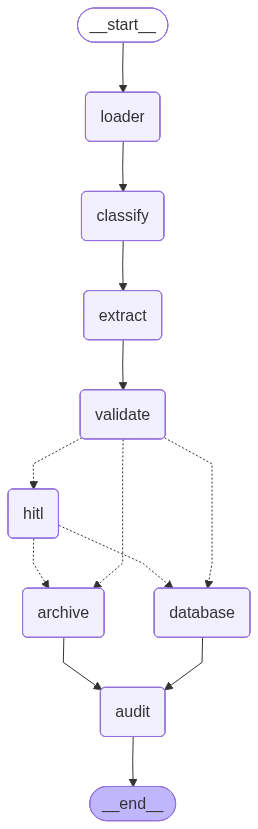

In [40]:
from IPython.display import Image, display

# Draw LangGraph workflow
display(Image(app.get_graph().draw_mermaid_png()))

# 15. Test Run

In [41]:
input_state = {
    "file_path": "Sample Docs/bw_doc_1.pdf"
}

result = app.invoke(input_state)

print("\nFINAL OUTPUT:\n")
print(result)


Processing: Sample Docs/bw_doc_1.pdf
📸 Image-based PDF
Chunks created: 1
ROUTING DECISION: Uncertain Human Review Required 0.4

HUMAN REVIEW REQUIRED
Document: bw_doc_1.pdf
Classification: {'label': 'Uncertain', 'confidence': 0.0, 'reason': 'The document content is unavailable for analysis.'}
Validation: Human Review Required
Extracted Data: {'document_type': 'Uncertain', 'error': 'Extraction failed', 'needs_review': True, 'extraction_confidence': 0.2}
Human Decision: Cease

FINAL OUTPUT:

{'file_path': 'Sample Docs/bw_doc_1.pdf', 'doc_name': 'bw_doc_1.pdf', 'text': 'SCANNED DOCUMENT: Unable to extract content. Please review manually.', 'chunks': ['SCANNED DOCUMENT: Unable to extract content. Please review manually.'], 'classification': {'label': 'Uncertain', 'confidence': 0.0, 'reason': 'The document content is unavailable for analysis.'}, 'extracted_data': {'document_type': 'Uncertain', 'error': 'Extraction failed', 'needs_review': True, 'extraction_confidence': 0.2}, 'validation': 

# 16. Batch Testing
* “Sample Docs → evaluate accuracy”

In [42]:
def batch_test(folder):
    for file in os.listdir(folder):
        if file.endswith(".pdf"):

            print(f"\nProcessing: {file}")

            # Only pass file_path (graph will handle everything)
            input_state = {
                "file_path": os.path.join(folder, file)
            }

            result = app.invoke(input_state)

            print("Classification:", result.get("classification"))
            print("Validation:", result.get("validation"))
            print("Final Route:",
                  "DB" if result.get("db_status") == "stored"
                  else "Archive" if result.get("archive_status") == "stored"
                  else "HITL")
            
batch_test("Sample Docs")


Processing: bw_doc_1.pdf

Processing: Sample Docs\bw_doc_1.pdf
📸 Image-based PDF
Chunks created: 1
ROUTING DECISION: Uncertain Human Review Required 0.1

HUMAN REVIEW REQUIRED
Document: bw_doc_1.pdf
Classification: {'label': 'Uncertain', 'confidence': 0.0, 'reason': 'The document content is unavailable for analysis.'}
Validation: Human Review Required
Extracted Data: {'document_type': 'Uncertain', 'error': 'Extraction failed', 'needs_review': True, 'extraction_confidence': 0.2}
Human Decision: Cease
Classification: {'label': 'Uncertain', 'confidence': 0.0, 'reason': 'The document content is unavailable for analysis.'}
Validation: Human Review Required
Final Route: HITL

Processing: bw_doc_2.pdf

Processing: Sample Docs\bw_doc_2.pdf
📸 Image-based PDF
Chunks created: 1
ROUTING DECISION: Uncertain Human Review Required 0.4

HUMAN REVIEW REQUIRED
Document: bw_doc_2.pdf
Classification: {'label': 'Uncertain', 'confidence': 0.0, 'reason': 'The document content is unavailable for analysis.'}


# 17. Evaluation Metrics
* “Track accuracy, audit, decisions”

In [44]:
import sqlite3
import pandas as pd

def display_db_table():
    conn = sqlite3.connect("cease_desist.db")

    df = pd.read_sql_query("SELECT * FROM cease_requests", conn)

    conn.close()

    return df


display_db_table()

,id,doc_name,received_date,document_type,confidence,details
